In [2]:
!pip install pandas

In [3]:
import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen

import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Initialize current pulse, membrane and outputs
# Initialize input current pulse
cur_in = torch.cat((torch.zeros(10, 1), torch.ones(190, 1)*0.1), 0)  # input current turns on at t=10

# Initialize membrane, output and recordings
mem = torch.zeros(1)  # membrane potential of 0 at t=0
spk_out = torch.zeros(1)  # neuron needs somewhere to sequentially dump its output spikes
mem_rec = [mem]

In [ ]:
a1, mem = snn.Leaky(beta=0.9)(torch.tensor([0.5, 0.5]), mem)

print(a1, mem)

tensor([0., 0.]) tensor([0.6694, 0.6694])


In [ ]:
a1, mem = snn.Leaky(beta=0.9)(torch.ones(2), mem)

print(a1, mem)

tensor([1., 1.]) tensor([1.1450, 1.1450])


In [ ]:
a1, mem = snn.Leaky(beta=0.9)(torch.zeros(2), mem)

print(a1, mem)

tensor([0., 0.]) tensor([0.0305, 0.0305])


In [ ]:
print(a1)
a2

tensor([0., 0.])


tensor([0.0305, 0.0305])

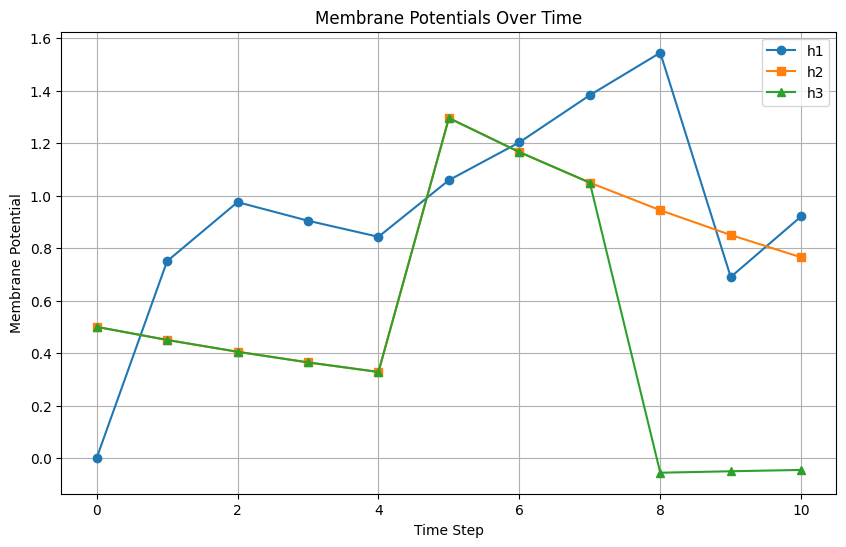

In [15]:
l1 = snn.Leaky(beta=0.9)
l2 = snn.Leaky(beta=0.9)
l3 = snn.Leaky(beta=0.9)

h1 = []
h2 =[]
h3 = []


time_steps = 10
mem1 = torch.zeros(1) 
mem2 = torch.zeros(1) 
mem3 = torch.zeros(1)

x1, mem1 = l1(torch.tensor([0.5]), mem1)
h1.append(x1)
x2, mem2 = l2(x1 + torch.tensor([0.5]), mem2)
h2.append(mem2)
x3, mem3 = l3(x2 + torch.tensor([0.5]), mem3)
h3.append(mem3)
for _ in range(time_steps):
  x1, mem1 = l1(x3[0] + torch.rand(1).clamp(-1, 0.3), mem1)
  h1.append(mem1)
  x2, mem2 = l2(x1, mem2)
  h2.append(mem2)
  x3, mem3 = l3(x2, mem3)
  h3.append(mem3)


plt.figure(figsize=(10, 6))
plt.plot(h1, label='h1', marker='o')
plt.plot(h2, label='h2', marker='s')
plt.plot(h3, label='h3', marker='^')
plt.xlabel('Time Step')
plt.ylabel('Membrane Potential')
plt.title('Membrane Potentials Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def create_neurons(num:int) -> list:
    neurons = []
    for i in range(num):
        neurons.append(snn.Leaky(beta=0.9))
    
    return neurons